# ノートブック12: 完全な機械学習パイプライン

## 学習目標

このノートブックでは、データ読み込みから本番環境へのデプロイまでの完全な機械学習パイプラインを構築します:

1. **Pipelineの基礎**
   - なぜPipelineが必要か
   - データリーク防止の仕組み
   - 再現性の確保

2. **パイプライン内でのチューニング**
   - GridSearchCVとの統合
   - パラメータ指定の方法

3. **特徴量エンジニアリング**
   - PolynomialFeatures
   - ColumnTransformer

4. **モデルの永続化**
   - joblibによる保存と読み込み
   - バージョン管理

5. **本番環境向けの実装**
   - 堅牢な予測関数
   - エラーハンドリング
   - デプロイへの道

---

In [1]:
# 必要なライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import joblib
import os
from datetime import datetime

# 日本語フォント設定（必要に応じて）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 乱数シード設定
np.random.seed(42)

# 日本語フォント設定
import matplotlib.font_manager as fm

def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro', 'AppleGothic',  # macOS
        'Yu Gothic', 'MS Gothic',  # Windows
        'Noto Sans CJK JP', 'IPAexGothic', 'TakaoPGothic',  # Linux
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
if font_used:
    print(f"Japanese font: {font_used}")


C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Japanese font: Yu Gothic


## 1. Pipelineの基礎

### 🤔 なぜPipelineが必要なのか？

機械学習では、前処理とモデル学習を**別々に行う**と問題が発生します。

```
【問題1: データリーク（最も深刻！）】

❌ よくある間違い:

  # 全データでスケーリング
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)  # ← 全データを使用
  
  # その後で分割
  X_train, X_test = train_test_split(X_scaled, ...)
  
  # モデル学習
  model.fit(X_train, y_train)

問題点:
  - スケーリング時にテストデータの情報を使っている
  - 平均・標準偏差にテストデータが含まれる
  - → 「未知データ」ではなくなる
  - → 性能が楽観的に評価される


✓ 正しい方法（Pipelineなし）:

  # まず分割
  X_train, X_test = train_test_split(X, ...)
  
  # 訓練データのみでfit
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
  X_test_scaled = scaler.transform(X_test)        # transformのみ
  
  # モデル学習
  model.fit(X_train_scaled, y_train)

→ 正しいが、コードが煩雑...
```

---

### 🔄 データリークの視覚的理解

```
【データリークが起こる仕組み】

全データ: [=== 訓練 ===][= テスト =]
              ↓              ↓
          両方の情報が混入
              ↓
          スケーラーのfit
              ↓
        mean = 全データの平均
        std  = 全データの標準偏差
              ↓
        テストデータの統計情報がリーク！


【Pipelineでの正しい処理】

Cross-validation時:

  Fold 1: [テスト][====== 訓練 ======]
                         ↓
                  この訓練データだけでfit
                         ↓
                    mean, std を計算
                         ↓
                  テストはtransformのみ

  Fold 2: [== 訓練 ==][テスト][== 訓練 ==]
                         ↓
                  この訓練データだけでfit
                         ↓
                    別の mean, std
                         ↓
                  テストはtransformのみ

→ 各FoldでScalerが独立に学習される
→ データリークなし！
```

---

### 🛠️ Pipelineの仕組み

```python
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),      # ステップ1: スケーリング
    ('classifier', MLPClassifier())     # ステップ2: 分類
])
```

```
【Pipelineの内部動作】

pipeline.fit(X_train, y_train) が呼ばれると:

  1. scaler.fit_transform(X_train)
     → 訓練データでfit、変換したデータを次へ
  
  2. classifier.fit(変換されたX_train, y_train)
     → モデル学習


pipeline.predict(X_test) が呼ばれると:

  1. scaler.transform(X_test)
     → 訓練で学習した統計量で変換（fit はしない！）
  
  2. classifier.predict(変換されたX_test)
     → 予測


【重要】
  fit_transform は訓練時のみ
  transform は予測時
  → データリークが自動的に防止される
```

---

### 📊 Pipelineの利点まとめ

| 問題 | Pipelineなし | Pipelineあり |
|------|-------------|-------------|
| データリーク | 発生しやすい | 自動防止 |
| コードの複雑さ | 高い | 低い |
| 再現性 | 確保が難しい | 自動確保 |
| デプロイ | 複数オブジェクト管理 | 1オブジェクト |
| CVでの前処理 | 手動で分離が必要 | 自動で正しく処理 |

---

### 🎯 Pipelineを使うべき場面

```
【常にPipelineを使うべき】

  ✓ スケーリング（StandardScaler, MinMaxScaler）
  ✓ 欠損値補完（SimpleImputer）
  ✓ 次元削減（PCA）
  ✓ 特徴量選択（SelectKBest）
  ✓ 特徴量生成（PolynomialFeatures）


【Pipelineに入れなくてもよいもの】

  ・データ型の変換（事前に1回だけ）
  ・カラム名の変更（事前に1回だけ）
  ・明らかに不要なカラムの削除（事前に1回だけ）
```

### Pipelineを使って乳がん診断モデルを構築しましょう

In [2]:
# データ読み込み（分類タスク）
cancer_data = load_breast_cancer()
X_cancer = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y_cancer = cancer_data.target

# データ分割
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print(f"訓練データサイズ: {X_train_c.shape}")
print(f"テストデータサイズ: {X_test_c.shape}")

訓練データサイズ: (455, 30)
テストデータサイズ: (114, 30)


In [3]:
# 基本的なPipelineの構築
pipeline_basic = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))
])

# Pipelineの学習
pipeline_basic.fit(X_train_c, y_train_c)

# Pipelineで予測
y_pred_basic = pipeline_basic.predict(X_test_c)
accuracy_basic = pipeline_basic.score(X_test_c, y_test_c)

print(f"基本的なPipelineの精度: {accuracy_basic:.4f}")
print("\nPipelineのステップ:")
print(pipeline_basic.steps)

基本的なPipelineの精度: 0.9474

Pipelineのステップ:
[('scaler', StandardScaler()), ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))]


## 2. パイプライン内でのハイパーパラメータチューニング

### 🔧 パイプラインパラメータの指定方法

Pipeline内の各ステップのパラメータは **`<ステップ名>__<パラメータ名>`** の形式で指定します。

```python
# パイプライン定義
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # ステップ名: 'scaler'
    ('classifier', MLPClassifier())          # ステップ名: 'classifier'
])

# パラメータグリッド
param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,)],  # classifier の hidden_layer_sizes
    'classifier__alpha': [0.001, 0.01],                  # classifier の alpha
}
```

---

### 🎯 GridSearchCVとPipelineの強力な組み合わせ

```
【なぜ一緒に使うと強力か？】

1. 前処理の選択もチューニング可能
   
   param_grid = {
       'scaler': [StandardScaler(), MinMaxScaler()],  # ← スケーラーの比較
       'classifier__C': [0.1, 1, 10],
   }
   
   → どのスケーラーが最適かも自動で探索！


2. データリークなしでCV
   
   各Foldで:
     1. 訓練データだけでスケーラーfit
     2. 訓練データを変換
     3. モデル学習
     4. テストデータを変換（fitなし）
     5. 評価
   
   → 全自動で正しい処理


3. 最良モデルがそのまま使える
   
   grid_search.best_estimator_
   → 最良パラメータで学習済みのPipeline
   → そのまま本番環境で使用可能
```

---

### 📊 パラメータ指定の例

```
【Pipelineの構造とパラメータ名】

Pipeline([
    ('step1', Transformer1()),
    ('step2', Transformer2()),
    ('step3', Model())
])

パラメータの指定方法:
  ・step1自体を変更: 'step1': [Obj1(), Obj2()]
  ・step1の属性:    'step1__param': [val1, val2]
  ・step3の属性:    'step3__param': [val1, val2]


【具体例】

pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('clf', SVC())
])

param_grid = {
    'poly__degree': [1, 2, 3],           # PolynomialFeatures の degree
    'poly__include_bias': [True, False], # PolynomialFeatures の include_bias
    'clf__C': [0.1, 1, 10],              # SVC の C
    'clf__kernel': ['rbf', 'linear'],    # SVC の kernel
}
```

---

### ⚠️ チューニング時の注意点

```
【探索空間の爆発に注意】

  例:
    scaler: 2種類
    hidden_layer_sizes: 3種類
    activation: 2種類
    alpha: 3種類
    learning_rate_init: 2種類
    
    合計: 2 × 3 × 2 × 3 × 2 = 72 通り
    
    5-fold CV なら: 72 × 5 = 360 回の学習
    
  → 時間がかかる！


【対策】

  1. まず粗い探索 → 絞り込んで細かく探索
  
  2. RandomizedSearchCV を使う
     → 全組み合わせでなくランダムサンプリング
  
  3. 段階的に探索
     → まずモデルの主要パラメータ
     → 次に前処理のパラメータ
```

### GridSearchCVでPipeline全体を最適化しましょう

In [4]:
# GridSearchCVでパイプライン全体を最適化
pipeline_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(max_iter=500, random_state=42))
])

# パラメータグリッド（前処理とモデルの両方）
param_grid = {
    # Scalerの選択（StandardScaler or MinMaxScaler）
    'scaler': [StandardScaler(), MinMaxScaler()],
    # MLPのパラメータ
    'classifier__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate_init': [0.001, 0.01]
}

# GridSearchCV実行
grid_search = GridSearchCV(
    pipeline_tuned,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV実行中...")
grid_search.fit(X_train_c, y_train_c)

print(f"\n最良スコア: {grid_search.best_score_:.4f}")
print(f"最良パラメータ:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

GridSearchCV実行中...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

最良スコア: 0.9802
最良パラメータ:
  classifier__activation: relu
  classifier__alpha: 0.0001
  classifier__hidden_layer_sizes: (50,)
  classifier__learning_rate_init: 0.001
  scaler: StandardScaler()


In [5]:
# テストデータでの評価
best_pipeline = grid_search.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test_c)
accuracy_tuned = best_pipeline.score(X_test_c, y_test_c)

print(f"チューニング後のテスト精度: {accuracy_tuned:.4f}")
print("\n詳細な分類レポート:")
print(classification_report(y_test_c, y_pred_tuned, target_names=cancer_data.target_names))

チューニング後のテスト精度: 0.9561

詳細な分類レポート:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



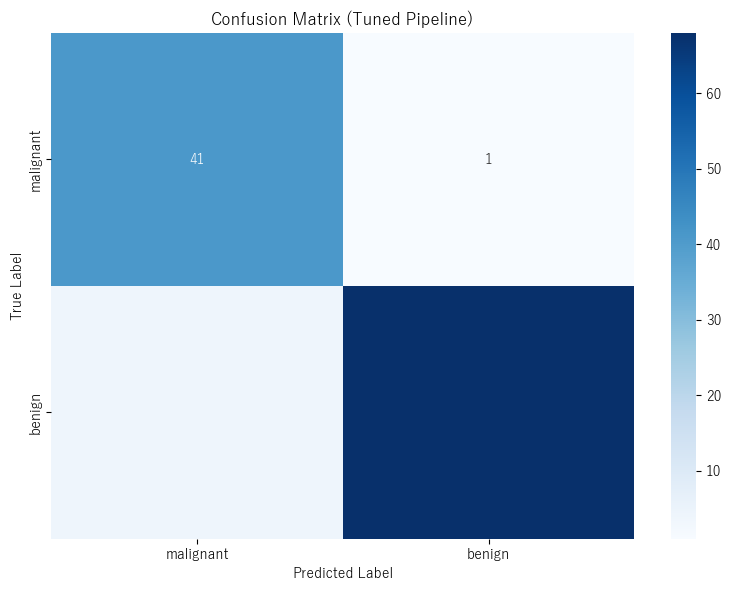


正解数: 109 / 114


In [6]:
# 混同行列の可視化
cm = confusion_matrix(y_test_c, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cancer_data.target_names,
            yticklabels=cancer_data.target_names)
plt.title('Confusion Matrix (Tuned Pipeline)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\n正解数: {cm.diagonal().sum()} / {cm.sum()}")

## 3. 複雑なパイプライン: 特徴量エンジニアリング

### 🔧 PolynomialFeatures（多項式特徴量）

線形モデルでも非線形パターンを捉えられるようにする手法です。

```
【PolynomialFeaturesの動作】

元の特徴量: [x1, x2]

degree=2 で変換:
  [1, x1, x2, x1², x1*x2, x2²]
       ↑   ↑   ↑     ↑    ↑
      元  元  2次  交互作用 2次


具体例:
  x1=2, x2=3 の場合
  
  → [1, 2, 3, 4, 6, 9]


【いつ使うか？】

  ✓ 線形モデルで非線形パターンを捉えたい
  ✓ 特徴量間の交互作用が重要そう
  
  ✗ すでに非線形モデル（NN, RF）を使っている場合は効果薄
  ✗ 特徴量が多い場合（次元爆発）
```

---

### 📊 ColumnTransformer（異なる前処理の適用）

実際のデータでは、**列によって異なる前処理**が必要です。

```
【典型的な状況】

  数値特徴量: スケーリングが必要
  カテゴリ特徴量: One-Hot エンコーディングが必要
  テキスト特徴量: TF-IDF変換が必要
  
  → 列ごとに異なる変換を適用したい


【ColumnTransformerの使い方】

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'income']),      # 数値列
        ('cat', OneHotEncoder(), ['gender', 'occupation']) # カテゴリ列
    ],
    remainder='passthrough'  # 指定しない列はそのまま
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
```

---

### 🎯 特徴量エンジニアリングの注意点

```
【Pipelineに含めるべき変換】

  ✓ スケーリング（訓練データの統計量を使用）
  ✓ 欠損値補完（訓練データの統計量を使用）
  ✓ 多項式特徴量（データに依存しないが、順序のため）
  ✓ PCA（訓練データで主成分を学習）


【Pipelineの外で行っても良い変換】

  ・カラム名の変更
  ・データ型の変換
  ・明らかに不要な列の削除
  ・ドメイン知識に基づく特徴量作成
    （例：日付から曜日を抽出）
```

### 多項式特徴量を含むパイプラインを試しましょう

In [7]:
# Synthetic housing data (replacing fetch_california_housing due to network restrictions)
np.random.seed(42)
X_housing_synthetic, y_housing_synthetic = make_regression(
    n_samples=1000, n_features=8, n_informative=8, noise=15, random_state=42
)
# Create a namespace object to mimic the dataset structure
class SyntheticHousingData:
    def __init__(self):
        self.data = X_housing_synthetic
        self.target = y_housing_synthetic
        # Scale target to realistic housing prices
        self.target = (self.target - self.target.min()) / (self.target.max() - self.target.min()) * 4 + 0.5
        self.feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                              'Population', 'AveOccup', 'Latitude', 'Longitude']

housing_data = SyntheticHousingData()
X_housing = pd.DataFrame(housing_data.data[:1000], columns=housing_data.feature_names)
y_housing = housing_data.target[:1000]

# データ分割
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print(f"回帰データサイズ: {X_train_h.shape}")


回帰データサイズ: (800, 8)


In [8]:
# 多項式特徴量を含むパイプライン
pipeline_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))
])

# 通常のパイプライン（比較用）
pipeline_normal = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))
])

# 両方のパイプラインを学習
print("通常のパイプライン学習中...")
pipeline_normal.fit(X_train_h, y_train_h)
print("多項式特徴量パイプライン学習中...")
pipeline_poly.fit(X_train_h, y_train_h)

# 予測と評価
y_pred_normal = pipeline_normal.predict(X_test_h)
y_pred_poly = pipeline_poly.predict(X_test_h)

r2_normal = r2_score(y_test_h, y_pred_normal)
r2_poly = r2_score(y_test_h, y_pred_poly)
rmse_normal = np.sqrt(mean_squared_error(y_test_h, y_pred_normal))
rmse_poly = np.sqrt(mean_squared_error(y_test_h, y_pred_poly))

print(f"\n通常のパイプライン - R²: {r2_normal:.4f}, RMSE: {rmse_normal:.4f}")
print(f"多項式特徴量パイプライン - R²: {r2_poly:.4f}, RMSE: {rmse_poly:.4f}")

通常のパイプライン学習中...
多項式特徴量パイプライン学習中...

通常のパイプライン - R²: 0.9570, RMSE: 0.1213
多項式特徴量パイプライン - R²: 0.7967, RMSE: 0.2640


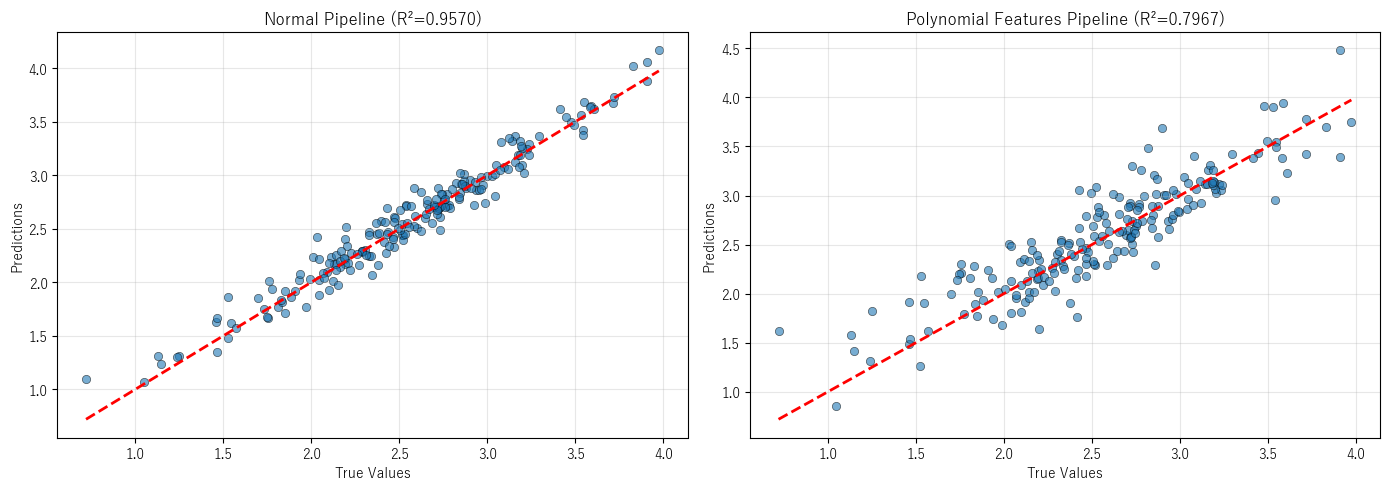

In [9]:
# 予測結果の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 通常のパイプライン
axes[0].scatter(y_test_h, y_pred_normal, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
axes[0].set_xlabel('True Values')
axes[0].set_ylabel('Predictions')
axes[0].set_title(f'Normal Pipeline (R²={r2_normal:.4f})')
axes[0].grid(True, alpha=0.3)

# 多項式特徴量パイプライン
axes[1].scatter(y_test_h, y_pred_poly, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
axes[1].set_xlabel('True Values')
axes[1].set_ylabel('Predictions')
axes[1].set_title(f'Polynomial Features Pipeline (R²={r2_poly:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. モデルの永続化（保存と読み込み）

### 💾 なぜモデルを保存するのか？

```
【モデル保存が必要な理由】

1. 本番環境へのデプロイ
   - 訓練済みモデルを本番サーバーに配置
   - 毎回訓練し直す必要がない
   
2. 再現性の確保
   - 特定時点のモデルを保存
   - 後で同じ予測を再現できる
   
3. 共有と協力
   - チームメンバーとモデルを共有
   - 同じモデルで評価を比較
   
4. バックアップ
   - 新モデルが劣化した場合のロールバック
   - 実験の記録
```

---

### 🔧 joblib vs pickle

```
【joblibを推奨する理由】

joblib:
  ✓ NumPy配列の保存に最適化
  ✓ 大きなモデル（RF, GBなど）で高速
  ✓ 圧縮オプションあり
  ✓ scikit-learn公式推奨

pickle:
  △ 汎用的なシリアライズ
  △ NumPy配列の最適化なし
  △ 大きなモデルで遅い


【使い方の比較】

# joblib（推奨）
import joblib
joblib.dump(model, 'model.pkl')
model = joblib.load('model.pkl')

# pickle
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)


【圧縮オプション】

# 圧縮して保存（ファイルサイズ削減）
joblib.dump(model, 'model.pkl.gz', compress=3)

# 圧縮レベル: 0-9（高いほど圧縮率高いが遅い）
```

---

### 📋 バージョン管理のベストプラクティス

```
【ファイル命名規則】

推奨フォーマット:
  <モデル名>_<バージョン>_<日時>.pkl
  
例:
  breast_cancer_classifier_v1.2_20240115_143052.pkl


【メタデータの保存】

モデルと一緒に保存すべき情報:
  - 訓練日時
  - 使用したデータのバージョン
  - ハイパーパラメータ
  - 評価指標
  - 依存ライブラリのバージョン

# メタデータ付きで保存
model_bundle = {
    'model': pipeline,
    'metadata': {
        'created_at': '2024-01-15 14:30:52',
        'sklearn_version': '1.3.0',
        'test_accuracy': 0.956,
        'params': grid_search.best_params_
    }
}
joblib.dump(model_bundle, 'model_bundle.pkl')
```

---

### ⚠️ セキュリティの注意

```
【pickle/joblibのセキュリティリスク】

  pickle形式のファイルは、読み込み時に
  任意のPythonコードを実行できる
  
  → 信頼できないソースのpklファイルを
    読み込んではいけない！


【対策】

  1. 信頼できるソースのモデルのみ使用
  
  2. モデルファイルのハッシュ値を確認
  
  3. 社内システムでは署名を使用
  
  4. 可能ならONNX等の安全な形式を検討
```

### モデルを保存して読み込んでみましょう

In [10]:
# モデル保存用ディレクトリの作成
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# タイムスタンプ付きのモデル名
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = os.path.join(model_dir, f'breast_cancer_classifier_{timestamp}.pkl')

# モデル保存
joblib.dump(best_pipeline, model_filename)
print(f"モデルを保存しました: {model_filename}")

# ファイルサイズの確認
file_size = os.path.getsize(model_filename) / 1024  # KB
print(f"ファイルサイズ: {file_size:.2f} KB")

モデルを保存しました: ../models\breast_cancer_classifier_20260301_004343.pkl
ファイルサイズ: 62.58 KB


In [11]:
# モデルの読み込み
loaded_pipeline = joblib.load(model_filename)
print("モデルを読み込みました")

# 読み込んだモデルで予測
y_pred_loaded = loaded_pipeline.predict(X_test_c)
accuracy_loaded = loaded_pipeline.score(X_test_c, y_test_c)

print(f"\n読み込んだモデルの精度: {accuracy_loaded:.4f}")
print(f"元のモデルの精度: {accuracy_tuned:.4f}")
print(f"予測結果が一致: {np.array_equal(y_pred_loaded, y_pred_tuned)}")

モデルを読み込みました

読み込んだモデルの精度: 0.9561
元のモデルの精度: 0.9561
予測結果が一致: True


## 5. 本番環境向けの予測関数

### 🏭 本番環境で必要なこと

研究・開発環境と本番環境では要求が異なります。

```
【開発環境】

  目標: モデルの性能を最大化
  
  ・エラーはデバッグ情報として表示
  ・データの品質は前提
  ・速度より精度を重視
  ・インタラクティブに実行


【本番環境】

  目標: 安定したサービス提供
  
  ・エラーは適切にハンドリング
  ・不正なデータへの対応
  ・レスポンス時間の保証
  ・24時間365日稼働
  ・ログによる監視
```

---

### 🛡️ 堅牢な予測関数の要件

```
【入力バリデーション】

  1. データ型の確認
     - DataFrame or ndarray?
     - 数値型か?
  
  2. 形状の確認
     - 特徴量の数は正しい?
     - 空のデータでない?
  
  3. 値の確認
     - 欠損値はない?
     - 異常値はない?（オプション）
  
  4. 特徴量の順序
     - 訓練時と同じ順序?
     - 必要な列が揃っている?


【エラーハンドリング】

  try:
      prediction = model.predict(X)
  except ValueError as e:
      # 入力データの問題
      log_error(e)
      return error_response("Invalid input data")
  except Exception as e:
      # 予期しないエラー
      log_error(e)
      return error_response("Internal error")


【ログ記録】

  記録すべき情報:
    - リクエスト日時
    - 入力データのサイズ
    - 予測結果
    - 処理時間
    - エラー（発生時）
```

---

### 📊 予測の信頼度

```
【なぜ信頼度が重要か】

  予測結果: クラスA
  
  信頼度 99%: 確信を持ってAと予測
  信頼度 51%: ほぼ半々、Bの可能性も高い
  
  → 信頼度が低い場合は人間の判断を仰ぐ等の対応


【信頼度の活用例】

  if confidence < 0.7:
      # 低信頼度 → 人間のレビューへ
      send_to_manual_review(sample)
  else:
      # 高信頼度 → 自動処理
      auto_process(prediction)
```

---

### 🔄 本番環境への道のり

```
【デプロイの選択肢】

1. バッチ処理
   - 定期的にまとめて予測
   - 例: 毎日深夜にスコアリング
   - 最もシンプル

2. REST API
   - HTTPリクエストで予測
   - Flask / FastAPI
   - リアルタイム処理

3. ストリーミング
   - リアルタイムデータ処理
   - Kafka + Spark
   - 大規模・低遅延

4. エッジデプロイ
   - モバイル/IoTデバイス上で推論
   - ONNX / TensorFlow Lite
   - オフライン対応


【段階的なデプロイ】

  Step 1: シャドウモード
          本番データで予測するが結果は使わない
          
  Step 2: カナリアリリース
          一部のトラフィックのみ新モデル
          
  Step 3: A/Bテスト
          旧モデルと新モデルを比較
          
  Step 4: 全面展開
          問題なければ100%切り替え
```

### 堅牢な予測クラスを実装しましょう

In [12]:
class ModelPredictor:
    """本番環境向けのモデル予測クラス"""
    
    def __init__(self, model_path, feature_names=None):
        """
        Parameters:
        -----------
        model_path : str
            学習済みモデルのパス
        feature_names : list, optional
            期待される特徴量名のリスト
        """
        self.model = joblib.load(model_path)
        self.feature_names = feature_names
        print(f"モデルを読み込みました: {model_path}")
    
    def validate_input(self, X):
        """入力データのバリデーション"""
        # DataFrameの場合
        if isinstance(X, pd.DataFrame):
            if self.feature_names is not None:
                # 特徴量名の確認
                if not all(col in X.columns for col in self.feature_names):
                    missing = set(self.feature_names) - set(X.columns)
                    raise ValueError(f"不足している特徴量: {missing}")
                # 特徴量の順序を揃える
                X = X[self.feature_names]
        
        # NumPy配列の場合
        elif isinstance(X, np.ndarray):
            if self.feature_names is not None:
                if X.shape[1] != len(self.feature_names):
                    raise ValueError(
                        f"特徴量数が一致しません。期待: {len(self.feature_names)}, 実際: {X.shape[1]}"
                    )
        else:
            raise TypeError("入力はpandas DataFrameまたはNumPy配列である必要があります")
        
        # 欠損値チェック
        if isinstance(X, pd.DataFrame):
            if X.isnull().any().any():
                raise ValueError("入力データに欠損値が含まれています")
        else:
            if np.isnan(X).any():
                raise ValueError("入力データに欠損値が含まれています")
        
        return X
    
    def predict(self, X):
        """予測を実行"""
        try:
            X = self.validate_input(X)
            predictions = self.model.predict(X)
            return predictions
        except Exception as e:
            print(f"予測エラー: {e}")
            raise
    
    def predict_proba(self, X):
        """確率予測を実行（分類モデルの場合）"""
        try:
            X = self.validate_input(X)
            if hasattr(self.model, 'predict_proba'):
                probabilities = self.model.predict_proba(X)
                return probabilities
            else:
                raise AttributeError("このモデルは確率予測をサポートしていません")
        except Exception as e:
            print(f"確率予測エラー: {e}")
            raise
    
    def get_model_info(self):
        """モデル情報の取得"""
        info = {
            'model_type': type(self.model).__name__,
            'feature_count': len(self.feature_names) if self.feature_names else 'Unknown'
        }
        
        # Pipelineの場合、ステップ情報を追加
        if hasattr(self.model, 'steps'):
            info['pipeline_steps'] = [step[0] for step in self.model.steps]
        
        return info

In [13]:
# ModelPredictorの使用例
predictor = ModelPredictor(
    model_path=model_filename,
    feature_names=cancer_data.feature_names.tolist()
)

# モデル情報の表示
print("\nモデル情報:")
for key, value in predictor.get_model_info().items():
    print(f"  {key}: {value}")

モデルを読み込みました: ../models\breast_cancer_classifier_20260301_004343.pkl

モデル情報:
  model_type: Pipeline
  feature_count: 30
  pipeline_steps: ['scaler', 'classifier']


In [14]:
# 単一サンプルの予測
sample_data = X_test_c.iloc[:5]  # 最初の5サンプル

predictions = predictor.predict(sample_data)
probabilities = predictor.predict_proba(sample_data)

print("予測結果:")
for i, (pred, proba) in enumerate(zip(predictions, probabilities)):
    print(f"サンプル {i+1}: 予測={cancer_data.target_names[pred]}, 確率={proba[pred]:.4f}")

予測結果:
サンプル 1: 予測=malignant, 確率=1.0000
サンプル 2: 予測=benign, 確率=1.0000
サンプル 3: 予測=malignant, 確率=0.9998
サンプル 4: 予測=malignant, 確率=0.8541
サンプル 5: 予測=malignant, 確率=1.0000


In [15]:
# エラーハンドリングのテスト

# 1. 欠損値を含むデータ
sample_with_nan = sample_data.copy()
sample_with_nan.iloc[0, 0] = np.nan

try:
    predictor.predict(sample_with_nan)
except ValueError as e:
    print(f"期待通りのエラー: {e}")

# 2. 特徴量が不足しているデータ
sample_missing_features = sample_data.iloc[:, :10]  # 最初の10特徴量のみ

try:
    predictor.predict(sample_missing_features)
except ValueError as e:
    print(f"期待通りのエラー: {e}")

予測エラー: 入力データに欠損値が含まれています
期待通りのエラー: 入力データに欠損値が含まれています
予測エラー: 不足している特徴量: {'worst smoothness', 'worst radius', 'worst concavity', 'fractal dimension error', 'worst texture', 'compactness error', 'symmetry error', 'worst area', 'worst fractal dimension', 'perimeter error', 'smoothness error', 'concave points error', 'worst perimeter', 'texture error', 'worst compactness', 'area error', 'radius error', 'worst concave points', 'worst symmetry', 'concavity error'}
期待通りのエラー: 不足している特徴量: {'worst smoothness', 'worst radius', 'worst concavity', 'fractal dimension error', 'worst texture', 'compactness error', 'symmetry error', 'worst area', 'worst fractal dimension', 'perimeter error', 'smoothness error', 'concave points error', 'worst perimeter', 'texture error', 'worst compactness', 'area error', 'radius error', 'worst concave points', 'worst symmetry', 'concavity error'}


## 6. 完全なMLワークフローの例

### 🔄 エンドツーエンドのワークフロー

```
【MLプロジェクトの全体像】

  ┌─────────────────────────────────────────────────────┐
  │                   1. 問題定義                        │
  │  「何を予測したいか」「成功基準は何か」を明確化      │
  └───────────────────────┬─────────────────────────────┘
                          ↓
  ┌─────────────────────────────────────────────────────┐
  │                 2. データ収集・理解                   │
  │  データの品質確認、探索的データ分析（EDA）           │
  └───────────────────────┬─────────────────────────────┘
                          ↓
  ┌─────────────────────────────────────────────────────┐
  │              3. データ前処理・特徴量設計              │
  │  欠損値処理、スケーリング、特徴量エンジニアリング    │
  └───────────────────────┬─────────────────────────────┘
                          ↓
  ┌─────────────────────────────────────────────────────┐
  │               4. モデル選択・学習                     │
  │  複数モデルの比較、ハイパーパラメータチューニング    │
  └───────────────────────┬─────────────────────────────┘
                          ↓
  ┌─────────────────────────────────────────────────────┐
  │                  5. モデル評価                        │
  │  テストデータでの評価、過学習チェック                │
  └───────────────────────┬─────────────────────────────┘
                          ↓
  ┌─────────────────────────────────────────────────────┐
  │              6. デプロイ・モニタリング                │
  │  本番環境への展開、性能監視、再学習                  │
  └─────────────────────────────────────────────────────┘
```

---

### 📋 各ステップでの成果物

| ステップ | 主な成果物 |
|---------|-----------|
| 問題定義 | 要件定義書、評価指標 |
| データ収集 | 生データ、EDAレポート |
| 前処理 | クリーンデータ、特徴量リスト |
| モデル学習 | 学習済みパイプライン |
| 評価 | 評価レポート、混同行列 |
| デプロイ | API/バッチ処理、監視ダッシュボード |

---

### 🎯 再利用可能なワークフロー関数

以下の関数は、データとモデル名を与えるだけで
完全なワークフローを実行します。

```python
def complete_ml_workflow(X, y, model_name):
    """
    完全なMLワークフロー
    
    1. データ分割
    2. パイプライン構築
    3. Cross-validation
    4. モデル学習
    5. 評価
    6. モデル保存
    
    Returns: 結果のdict
    """
```

### 完全なワークフロー関数を実装して実行しましょう

In [16]:
def complete_ml_workflow(X, y, test_size=0.2, model_name='ml_model'):
    """
    完全な機械学習ワークフロー
    
    Parameters:
    -----------
    X : array-like or DataFrame
        特徴量データ
    y : array-like
        ターゲット変数
    test_size : float
        テストデータの割合
    model_name : str
        保存するモデルの名前
    
    Returns:
    --------
    dict : ワークフローの結果
    """
    print("=" * 60)
    print("完全なMLワークフロー開始")
    print("=" * 60)
    
    # ステップ1: データ分割
    print("\n[1/6] データ分割...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    print(f"  訓練データ: {X_train.shape[0]} サンプル")
    print(f"  テストデータ: {X_test.shape[0]} サンプル")
    
    # ステップ2: パイプライン構築
    print("\n[2/6] パイプライン構築...")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    print("  パイプラインステップ:", [step[0] for step in pipeline.steps])
    
    # ステップ3: Cross-validation
    print("\n[3/6] Cross-validation...")
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    print(f"  CVスコア: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # ステップ4: モデル学習
    print("\n[4/6] モデル学習...")
    pipeline.fit(X_train, y_train)
    print("  学習完了")
    
    # ステップ5: モデル評価
    print("\n[5/6] モデル評価...")
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    print(f"  訓練スコア: {train_score:.4f}")
    print(f"  テストスコア: {test_score:.4f}")
    
    # ステップ6: モデル保存
    print("\n[6/6] モデル保存...")
    model_path = os.path.join(model_dir, f'{model_name}.pkl')
    joblib.dump(pipeline, model_path)
    print(f"  保存先: {model_path}")
    
    print("\n" + "=" * 60)
    print("ワークフロー完了")
    print("=" * 60)
    
    return {
        'pipeline': pipeline,
        'cv_scores': cv_scores,
        'train_score': train_score,
        'test_score': test_score,
        'model_path': model_path,
        'X_test': X_test,
        'y_test': y_test
    }

In [17]:
# 完全ワークフローの実行
workflow_result = complete_ml_workflow(
    X=X_cancer,
    y=y_cancer,
    test_size=0.2,
    model_name='breast_cancer_rf_pipeline'
)

完全なMLワークフロー開始

[1/6] データ分割...
  訓練データ: 455 サンプル
  テストデータ: 114 サンプル

[2/6] パイプライン構築...
  パイプラインステップ: ['scaler', 'classifier']

[3/6] Cross-validation...
  CVスコア: 0.9582 (+/- 0.0352)

[4/6] モデル学習...
  学習完了

[5/6] モデル評価...
  訓練スコア: 1.0000
  テストスコア: 0.9649

[6/6] モデル保存...
  保存先: ../models\breast_cancer_rf_pipeline.pkl

ワークフロー完了


モデルを読み込みました: ../models\breast_cancer_rf_pipeline.pkl


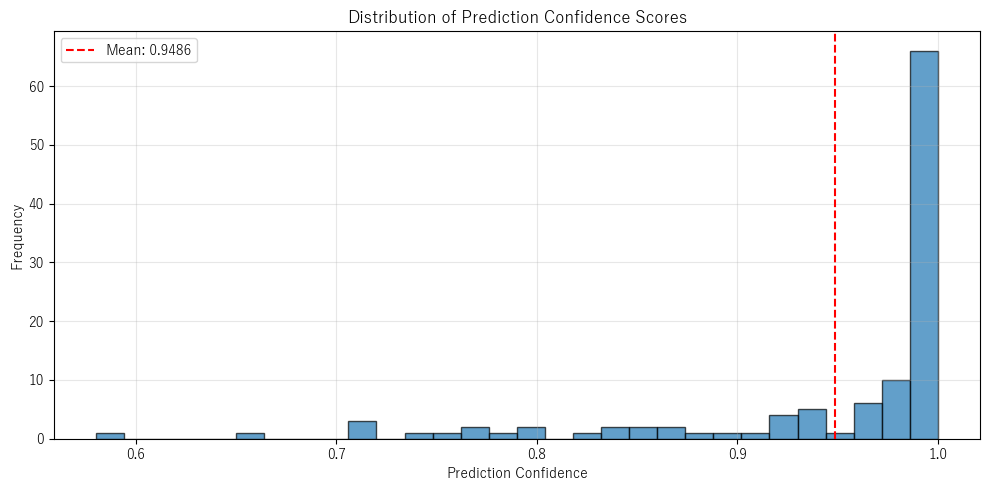

平均信頼度: 0.9486
最小信頼度: 0.5800
最大信頼度: 1.0000


In [18]:
# 保存したモデルを使った予測
production_predictor = ModelPredictor(
    model_path=workflow_result['model_path'],
    feature_names=cancer_data.feature_names.tolist()
)

# テストデータで予測
test_predictions = production_predictor.predict(workflow_result['X_test'])
test_probabilities = production_predictor.predict_proba(workflow_result['X_test'])

# 予測の信頼度分布
confidence_scores = np.max(test_probabilities, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(confidence_scores, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence Scores')
plt.axvline(confidence_scores.mean(), color='red', linestyle='--', 
            label=f'Mean: {confidence_scores.mean():.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"平均信頼度: {confidence_scores.mean():.4f}")
print(f"最小信頼度: {confidence_scores.min():.4f}")
print(f"最大信頼度: {confidence_scores.max():.4f}")

## 7. ベストプラクティスとチェックリスト

### ✅ データ準備チェックリスト

```
□ データの品質を確認した
  ・欠損値の割合と対処法
  ・外れ値の確認
  ・データ型の確認

□ 探索的データ分析（EDA）を実施した
  ・分布の確認
  ・相関関係の確認
  ・ターゲット変数の分布

□ 適切なtrain/test分割を行った
  ・stratify（分類の場合）
  ・random_stateの固定
  ・時系列の場合はシャッフルなし
```

---

### ✅ モデル開発チェックリスト

```
□ Pipelineを使用して前処理とモデルを統合した
  ・データリーク防止
  ・再現性の確保

□ Cross-validationで汎化性能を評価した
  ・適切なfold数（5-10）
  ・Stratified（分類の場合）

□ ハイパーパラメータチューニングを実施した
  ・GridSearchCV or RandomizedSearchCV
  ・探索空間の適切な設定

□ 過学習を確認した
  ・訓練スコア vs テストスコア
  ・学習曲線の確認
```

---

### ✅ モデル評価チェックリスト

```
□ 適切な評価指標を選択した
  ・分類: Accuracy, F1, AUC-ROC, 混同行列
  ・回帰: RMSE, MAE, R²

□ テストデータで最終評価を行った
  ・テストデータは最後まで使わない
  ・一度だけ評価

□ 誤分類/誤予測の分析を行った
  ・どのようなケースで間違えやすいか
  ・改善の余地はあるか
```

---

### ✅ デプロイ準備チェックリスト

```
□ モデルをjoblibで保存した
  ・タイムスタンプ付きファイル名
  ・メタデータも保存

□ 予測関数にバリデーションを実装した
  ・入力データ型のチェック
  ・特徴量数のチェック
  ・欠損値のチェック

□ エラーハンドリングを実装した
  ・例外の適切な処理
  ・ユーザーフレンドリーなエラーメッセージ

□ ドキュメントを作成した
  ・モデルの使用方法
  ・入力形式の説明
  ・制限事項の説明

□ モニタリング計画を立てた
  ・予測分布の監視
  ・性能劣化の検知
  ・再学習のトリガー
```

---

### ⚠️ よくある間違いと対策

| 間違い | 問題点 | 対策 |
|--------|--------|------|
| 全データでスケーリング | データリーク | Pipeline使用 |
| テストデータで何度も評価 | 過度な最適化 | CVで調整、テストは最後に1回 |
| random_state未設定 | 再現性なし | 常に固定 |
| 前処理とモデルを別保存 | デプロイ困難 | Pipelineで統合 |
| エラー処理なし | 本番で障害 | try-except実装 |
| バージョン管理なし | ロールバック不可 | タイムスタンプ付き保存 |

## まとめ

### 🎯 このノートブックで学んだこと

```
1. Pipelineの重要性
   - データリーク防止の仕組み
   - 前処理とモデルの統合
   - 再現性と保守性の向上

2. ハイパーパラメータチューニング
   - <ステップ名>__<パラメータ名> 形式
   - GridSearchCVとの統合
   - 前処理の選択もチューニング可能

3. 特徴量エンジニアリング
   - PolynomialFeatures
   - ColumnTransformer

4. モデルの永続化
   - joblibによる保存・読み込み
   - バージョン管理の重要性
   - セキュリティの考慮

5. 本番環境向けの実装
   - 入力バリデーション
   - エラーハンドリング
   - 予測の信頼度
   - デプロイ戦略

6. 完全なワークフロー
   - 問題定義からデプロイまで
   - 再利用可能な関数設計
```

---

### 📊 Pipelineチートシート

```python
# 基本的なPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier())
])

# 学習と予測
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

# パラメータアクセス
pipeline.get_params()
pipeline.set_params(classifier__alpha=0.01)

# GridSearchCVとの統合
from sklearn.model_selection import GridSearchCV

param_grid = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'classifier__hidden_layer_sizes': [(50,), (100,)],
    'classifier__alpha': [0.001, 0.01]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# モデル保存
import joblib
joblib.dump(best_model, 'model.pkl')
loaded_model = joblib.load('model.pkl')
```

---

### 🛠️ ColumnTransformerの例

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 数値列とカテゴリ列で異なる前処理
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), ['age', 'income', 'score']),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), ['gender', 'city', 'category'])
    ],
    remainder='drop'  # 指定していない列は削除
)

# Pipelineに組み込み
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
```

---

### 🏭 本番デプロイのテンプレート

```python
class ProductionModel:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)
        
    def predict(self, data):
        # バリデーション
        self._validate(data)
        
        # 予測
        try:
            return self.model.predict(data)
        except Exception as e:
            self._log_error(e)
            raise
    
    def _validate(self, data):
        if data.isnull().any().any():
            raise ValueError("欠損値があります")
        # 追加のバリデーション...
    
    def _log_error(self, error):
        # ログ記録
        pass
```

---

### 📚 次のステップ

```
【さらに学ぶべきこと】

1. MLOpsツール
   - MLflow: 実験管理、モデルレジストリ
   - DVC: データバージョン管理
   - Kubeflow: Kubernetes上のML

2. 高度なデプロイ
   - Flask/FastAPI でREST API
   - Docker コンテナ化
   - クラウドサービス（AWS SageMaker等）

3. モデルモニタリング
   - データドリフト検知
   - 性能劣化検知
   - 自動再学習

4. スケーラブルなML
   - 分散学習
   - バッチ推論の最適化
   - モデル軽量化
```

---

### ✅ 学習チェックリスト

- [ ] Pipelineがデータリークを防ぐ仕組みを説明できる
- [ ] `<ステップ名>__<パラメータ名>` 形式でパラメータを指定できる
- [ ] joblibでモデルを保存・読み込みできる
- [ ] バリデーション付きの予測関数を実装できる
- [ ] 完全なMLワークフローを設計できる

---

### 📚 練習問題

1. **Pipelineの構築**: Irisデータセットで、スケーリング→PCA→SVMのPipelineを構築してください

2. **チューニング**: GridSearchCVで前処理の選択も含めて最適化してください

3. **ColumnTransformer**: 数値列とカテゴリ列が混在するデータで、適切な前処理Pipelineを構築してください

4. **予測クラス**: 本ノートブックのModelPredictorクラスに、ログ記録機能を追加してください

5. **デプロイ**: 保存したモデルをFlaskでREST APIとして提供する簡単なアプリを作成してください

---

**シリーズ完結！**

このシリーズを通じて、機械学習の基礎から本番環境へのデプロイまでを学びました。
次は実際のプロジェクトでこれらの知識を活用してください！